# 13.3 案例实战 - 新闻聚类分群模型

In [2]:
import pandas as pd
df = pd.read_excel(r"D:\1Ftostudy\商业数据分析\@Python大数据分析与机器学习商业案例实战\@Python大数据分析与机器学习商业案例实战\第13章 数据聚类与分群\源代码汇总_Jupyter Notebook格式（推荐）\新闻.xlsx")
df.head() #

,关键词,标题,网址,来源,时间
0,华能信托,信托公司2019年上半年经营业绩概览,http://www.financialnews.com.cn/jrsb_m/xt/zx/2...,中国金融新闻网,2019年07月23日 00:00
1,华能信托,首单信托型企业ABS获批,http://www.jjckb.cn/2018-10/23/c_137552198.htm,经济参考网,2018年10月23日 12:21
2,华能信托,华能贵诚信托孙磊:金融科技助力打造开放信托生态,https://baijiahao.baidu.com/s?id=1639276579449...,同花顺财经,2019年07月17日 10:49
3,华能信托,华能贵诚信托孙磊:金融科技已经成为信托行业重要的基础设施,https://finance.qq.com/a/20190716/007898.htm,腾讯财经,2019年07月16日 18:53
4,华能信托,格力电器股权转让意向方闭门开会 华能信托赫然在列,https://finance.sina.com.cn/trust/roll/2019-05...,新浪,2019年05月22日 22:53


In [4]:
df.shape

(962, 5)

In [7]:
pip install jieba

In [11]:
# 中文分词演示 - 优化版本
import jieba
import logging

# 关闭jieba的调试信息
jieba.setLogLevel(logging.INFO)

word = jieba.cut('我爱北京天安门')
for i in word:
    print(i)

我
爱
北京
天安门


In [13]:
# 第一条新闻标题
df.iloc[0]['标题']

'信托公司2019年上半年经营业绩概览'

In [15]:
# 第一条新闻标题中文分词
import jieba
word = jieba.cut(df.iloc[0]['标题'])
result = ' '.join(word)
print(result)

信托公司 2019 年 上半年 经营 业绩 概览


In [17]:
# 通过for循环遍历来进行所有标题的分词
import jieba
words = []
for i, row in df.iterrows():
    word = jieba.cut(row['标题'])
    result = ' '.join(word) 
    words.append(result)

In [19]:
words[0:3]  # 展示前三条新闻的分词结果

['信托公司 2019 年 上半年 经营 业绩 概览',
 '首单 信托 型 企业 ABS 获批',
 '华能 贵 诚信 托孙磊 : 金融 科技 助力 打造 开放 信托 生态']

In [21]:
# 熟悉了上面的过程后，可以把代码合并写成如下形式
import jieba
words = []
for i, row in df.iterrows():
    words.append(' '.join(jieba.cut(row['标题'])))

In [23]:
words[0:3]  # 同样展示前三条新闻的分词结果

['信托公司 2019 年 上半年 经营 业绩 概览',
 '首单 信托 型 企业 ABS 获批',
 '华能 贵 诚信 托孙磊 : 金融 科技 助力 打造 开放 信托 生态']

In [25]:
for i, row in df.iterrows():
    print(i)
    print(row)

0
关键词                                                 华能信托
标题                                    信托公司2019年上半年经营业绩概览
网址     http://www.financialnews.com.cn/jrsb_m/xt/zx/2...
来源                                               中国金融新闻网
时间                                     2019年07月23日 00:00
Name: 0, dtype: object
1
关键词                                              华能信托
标题                                       首单信托型企业ABS获批
网址     http://www.jjckb.cn/2018-10/23/c_137552198.htm
来源                                              经济参考网
时间                                  2018年10月23日 12:21
Name: 1, dtype: object
2
关键词                                                 华能信托
标题                               华能贵诚信托孙磊:金融科技助力打造开放信托生态
网址     https://baijiahao.baidu.com/s?id=1639276579449...
来源                                                 同花顺财经
时间                                     2019年07月17日 10:49
Name: 2, dtype: object
3
关键词                                            华能信托
标题                     华能贵诚信托孙磊

In [27]:
# CountVectorizer()函数简单演示
from sklearn.feature_extraction.text import CountVectorizer  #将文本转化为数值
test = ['金融 科技 厉害', '华能 信托 厉害']
vect = CountVectorizer()
X = vect.fit_transform(test)
X = X.toarray()

In [29]:
print(X)

[[0 0 1 1 1]
 [1 1 1 0 0]]


In [31]:
# 查看词袋和对应的顺序
words_bag = vect.vocabulary_
print(words_bag)

{'金融': 4, '科技': 3, '厉害': 2, '华能': 1, '信托': 0}


In [33]:
# 将之前所有的新闻标题进行文本向量化
from sklearn.feature_extraction.text import CountVectorizer
vect = CountVectorizer()
X = vect.fit_transform(words)
X = X.toarray()

In [35]:
print(X)   # 展示词频矩阵

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [37]:
# 查看所有新闻标题的词袋
words_bag = vect.vocabulary_
print(words_bag)

{'信托公司': 630, '2019': 21, '上半年': 296, '经营': 2659, '业绩': 345, '概览': 2130, '首单': 3337, '信托': 628, '企业': 538, 'abs': 103, '获批': 2827, '华能': 896, '诚信': 2947, '托孙磊': 1721, '金融': 3199, '科技': 2541, '助力': 854, '打造': 1720, '开放': 1553, '生态': 2408, '已经': 1467, '成为': 1673, '行业': 2860, '重要': 3191, '基础设施': 1135, '格力电器': 2116, '股权': 2754, '转让': 3063, '意向': 1664, '闭门': 3229, '开会': 1535, '赫然': 3013, '直击': 2465, '投资者': 1744, '见面会': 2886, '参会者': 934, '背后': 2758, '国务院': 1091, '国资委': 1098, '召开': 972, '自称': 2784, '人士': 492, '到场': 818, '2018': 20, '信托业': 629, '人均': 491, '创利': 798, '304': 44, '万元': 273, '华润': 895, '贵诚': 2992, '跌出': 3039, '万亿': 272, '俱乐部': 633, '去年': 932, '托跌出': 1724, '200': 17, '收购': 1854, '50': 60, '亿爆雷': 508, '烫手山芋': 2323, '如何': 1269, '处置': 1152, '外界': 1159, '传言': 564, '泰禾': 2221, '引进': 1566, '战投': 1695, '目标': 2464, '之一': 407, '行业动态': 2861, '山东': 1438, '年报': 1497, '规模': 2890, '缩水': 2686, '曲线': 2021, '上市': 297, '浪潮': 2241, '再度': 739, '托换帅': 1722, '孙磊': 1303, '出任': 764, '总经理': 1641, '换帅': 179

In [39]:
# 查看词袋中词的数目
len(words_bag)

3402

In [43]:
# 将之前所有的新闻标题进行文本向量化并通过pandas展示
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# 文本向量化
vect = CountVectorizer()
X = vect.fit_transform(words)
X = X.toarray()

# 兼容新旧版本的查看词袋方法
try:
    # 尝试新版本方法
    words_bag2 = vect.get_feature_names_out()
except AttributeError:
    # 如果新版本方法不存在，使用旧版本方法
    words_bag2 = vect.get_feature_names()

df = pd.DataFrame(X, columns=words_bag2)
df.head()

,00700,03,04,08s,09,10,100,11,12,150,...,黄萍,黄金,黑客,黑灰产,黑金,黑马,鼓手,鼻祖,齐聚,龙风
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 高斯混合模型

In [54]:
# 模型搭建与使用
from sklearn.mixture import GaussianMixture
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 文本向量化（使用TF-IDF）
vectorizer = TfidfVectorizer(max_features=1000, max_df=0.5, min_df=2)
X = vectorizer.fit_transform(words)

# 使用高斯混合模型聚类，使用random初始化避免kmeans
n_components = 5  # 假设分为5个成分
gmm = GaussianMixture(
    n_components=n_components, 
    random_state=42, 
    covariance_type='full',
    init_params='random'  # 使用random初始化而不是kmeans
)
gmm_labels = gmm.fit_predict(X.toarray())

# 将聚类结果添加到DataFrame中
df['GMM_Cluster'] = gmm_labels

# 查看每个簇的新闻数量
print("GMM聚类结果：")
print(df['GMM_Cluster'].value_counts().sort_index())

# 查看每个簇的概率
probs = gmm.predict_proba(X.toarray())
print("\n前5个样本的聚类概率：")
print(probs[:5])

GMM聚类结果：
GMM_Cluster
0    203
1    214
2    213
3    187
4    145
Name: count, dtype: int64

前5个样本的聚类概率：
[[0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [1. 0. 0. 0. 0.]]


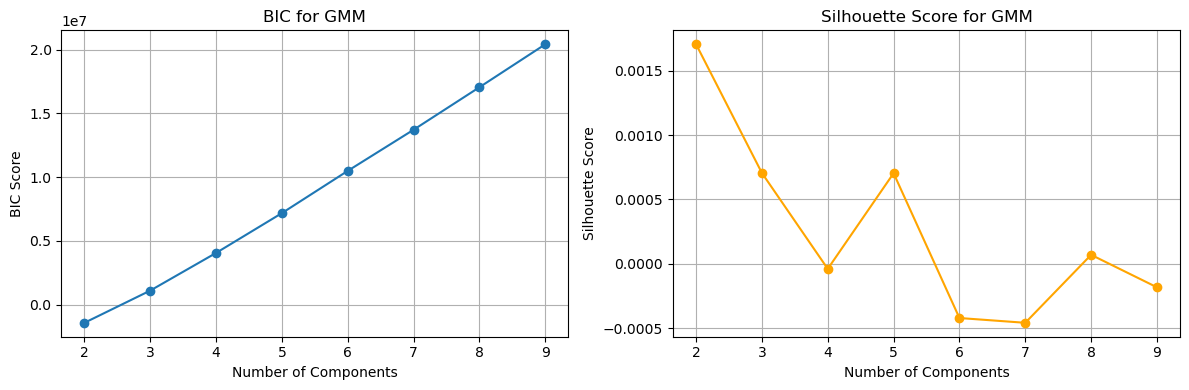

Best number of components: 2

优化后的GMM聚类结果：
GMM_Cluster_Optimized
0    514
1    448
Name: count, dtype: int64


In [72]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"

from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

# 模型优化
bic_scores = []
silhouette_scores = []
n_components_range = range(2, 10)

# 将稀疏矩阵转换为密集矩阵，避免重复转换
X_dense = X.toarray()

for n in n_components_range:
    # 使用随机初始化而不是k-means
    gmm = GaussianMixture(
        n_components=n, 
        random_state=42, 
        covariance_type='full',
        init_params='random'  # 使用随机初始化而不是k-means
    )
    labels = gmm.fit_predict(X_dense)
    
    # 计算BIC
    bic_scores.append(gmm.bic(X_dense))
    
    # 计算轮廓系数
    n_samples = X.shape[0]  # 使用 shape[0] 获取样本数量
    if n_samples > 1000:
        # 随机抽样计算轮廓系数
        sample_indices = np.random.choice(n_samples, 1000, replace=False)
        sample_score = silhouette_score(X_dense[sample_indices], labels[sample_indices])
    else:
        sample_score = silhouette_score(X_dense, labels)
    silhouette_scores.append(sample_score)

# 绘制BIC和轮廓系数图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# BIC图（越小越好）
ax1.plot(n_components_range, bic_scores, marker='o')
ax1.set_xlabel('Number of Components')
ax1.set_ylabel('BIC Score')
ax1.set_title('BIC for GMM')
ax1.grid(True)

# 轮廓系数图（越大越好）
ax2.plot(n_components_range, silhouette_scores, marker='o', color='orange')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score for GMM')
ax2.grid(True)

plt.tight_layout()
plt.show()

# 选择最佳成分数（基于轮廓系数）
best_n_components = n_components_range[np.argmax(silhouette_scores)]
print(f"Best number of components: {best_n_components}")

# 使用最佳成分数重新聚类
gmm_optimized = GaussianMixture(
    n_components=best_n_components, 
    random_state=42, 
    covariance_type='full',
    init_params='random'
)
df['GMM_Cluster_Optimized'] = gmm_optimized.fit_predict(X_dense)

print("\n优化后的GMM聚类结果：")
print(df['GMM_Cluster_Optimized'].value_counts().sort_index())

## 层次聚类

In [139]:
# 模型搭建与使用
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import pandas as pd

# 假设 X 是 TF-IDF 向量化后的结果（稀疏矩阵）
X_dense = X.toarray()  # 转换为稠密矩阵

agg_model = AgglomerativeClustering(n_clusters=5, linkage='ward')
agg_labels = agg_model.fit_predict(X_dense)

# 查看聚类结果
print(pd.Series(agg_labels).value_counts())


0    843
1     58
2     43
3     10
4      8
Name: count, dtype: int64


n_clusters=2, silhouette_score=0.0147
n_clusters=3, silhouette_score=0.0162
n_clusters=4, silhouette_score=0.0131
n_clusters=5, silhouette_score=0.0163
n_clusters=6, silhouette_score=0.0170
n_clusters=7, silhouette_score=0.0226
n_clusters=8, silhouette_score=0.0295
n_clusters=9, silhouette_score=0.0360


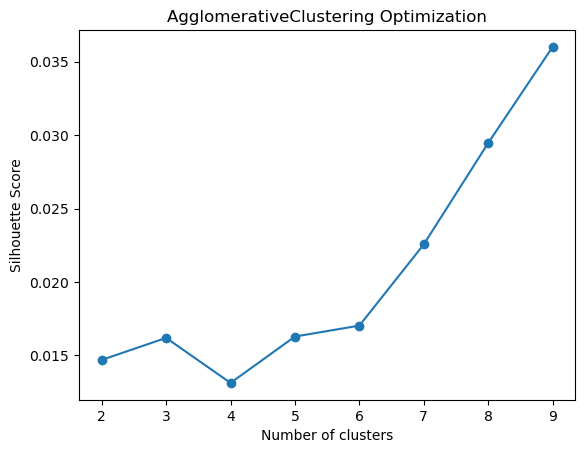

最优聚类数为: 9


In [143]:
# 层次聚类模型优化：通过轮廓系数(silhouette score)选择最优聚类数
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 将稀疏矩阵转换为稠密矩阵
X_dense = X.toarray()

scores = []
clusters_range = range(2, 10)

for n in clusters_range:
    model = AgglomerativeClustering(n_clusters=n, linkage='ward')
    labels = model.fit_predict(X_dense)
    score = silhouette_score(X_dense, labels)
    scores.append(score)
    print(f"n_clusters={n}, silhouette_score={score:.4f}")

# 可视化结果
plt.plot(clusters_range, scores, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.title("AgglomerativeClustering Optimization")
plt.show()

best_n = clusters_range[scores.index(max(scores))]
print(f"最优聚类数为: {best_n}")


## 谱聚类

In [171]:
import os
import sys
import subprocess
from pathlib import Path

print("🔧 Step 1. 卸载旧版本库...")
subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "numpy", "scipy", "scikit-learn", "threadpoolctl"])

numpy_libs = Path(sys.prefix) / "Lib" / "site-packages" / "numpy.libs"

print("\n🧹 Step 2. 检查并删除旧的 OpenBLAS DLL 文件...")
if numpy_libs.exists():
    for dll in numpy_libs.glob("libopenblas*.dll"):
        try:
            print(f" - 删除旧 DLL: {dll}")
            dll.unlink()
        except Exception as e:
            print(f" ⚠️ 无法删除 {dll}: {e}")
else:
    print("未找到 numpy.libs 目录（说明 numpy 已卸载干净）")

print("\n📦 Step 3. 安装稳定版 numpy / scipy / sklearn / threadpoolctl ...")
subprocess.run([
    sys.executable, "-m", "pip", "install",
    "numpy==1.26.4", "scipy==1.13.1", "scikit-learn==1.5.2", "threadpoolctl==3.5.0"
])

print("\n🔍 Step 4. 验证修复结果...")
subprocess.run([sys.executable, "-m", "threadpoolctl", "-i", "numpy", "scipy"])

print("\n✅ 修复完成！请确认输出中 version 不含 '.dev'，若成功请重启 Jupyter 内核。")


🔧 Step 1. 卸载旧版本库...

🧹 Step 2. 检查并删除旧的 OpenBLAS DLL 文件...
未找到 numpy.libs 目录（说明 numpy 已卸载干净）

📦 Step 3. 安装稳定版 numpy / scipy / sklearn / threadpoolctl ...

🔍 Step 4. 验证修复结果...

✅ 修复完成！请确认输出中 version 不含 '.dev'，若成功请重启 Jupyter 内核。


In [5]:
#模型搭建与使用
import os
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import numpy as np
from sklearn.cluster import SpectralClustering

X = np.random.rand(100, 5)
model = SpectralClustering(n_clusters=3, random_state=42)
labels = model.fit_predict(X)
print(np.bincount(labels))


[35 35 30]


n_clusters=2, silhouette_score=0.1756
n_clusters=3, silhouette_score=0.1798
n_clusters=4, silhouette_score=0.1782
n_clusters=5, silhouette_score=0.1781
n_clusters=6, silhouette_score=0.1905
n_clusters=7, silhouette_score=0.1754
n_clusters=8, silhouette_score=0.1736
n_clusters=9, silhouette_score=0.1798


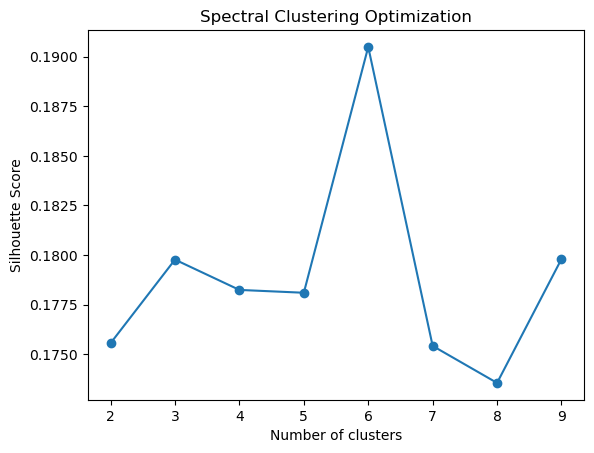

最优聚类数为: 6


In [7]:
#模型优化
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 设置不同的聚类数范围
scores = []
clusters_range = range(2, 10)

for n in clusters_range:
    model = SpectralClustering(n_clusters=n, random_state=42, assign_labels='kmeans')
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)
    scores.append(score)
    print(f"n_clusters={n}, silhouette_score={score:.4f}")

# 绘制轮廓系数变化图
plt.plot(clusters_range, scores, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.title("Spectral Clustering Optimization")
plt.show()

best_n = clusters_range[scores.index(max(scores))]
print(f"最优聚类数为: {best_n}")
